<a href="https://colab.research.google.com/github/NehaMusale11/Machine-Vision/blob/main/Practical_06_MachineV_CM23057_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q kagglehub

In [3]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("nicolejyt/facialexpressionrecognition")

print("Path to dataset files:", path)

print(os.listdir(path))

100%|██████████| 96.6M/96.6M [00:01<00:00, 81.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nicolejyt/facialexpressionrecognition/versions/1
['fer2013.csv']


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [5]:
csv_path = os.path.join(path, "fer2013.csv")

df = pd.read_csv(csv_path)

df.head()

,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [6]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nEmotion Counts:")
print(df["emotion"].value_counts())

Dataset Shape: (35887, 3)

Columns:
Index(['emotion', 'pixels', 'Usage'], dtype='object')

Emotion Counts:
emotion
3    8989
6    6198
4    6077
2    5121
0    4953
5    4002
1     547
Name: count, dtype: int64


In [6]:
!pip install -q kagglehub

import kagglehub
import os

path = kagglehub.dataset_download("nicolejyt/facialexpressionrecognition")

print(path)
print(os.listdir(path))

Using Colab cache for faster access to the 'facialexpressionrecognition' dataset.
/kaggle/input/facialexpressionrecognition
['fer2013.csv']


In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [8]:
csv_file = os.path.join(path, "fer2013.csv")

df = pd.read_csv(csv_file)

print(df.head())
print(df.columns)
print(df.shape)

   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training
Index(['emotion', 'pixels', 'Usage'], dtype='object')
(35887, 3)


In [9]:
X = np.stack(df["pixels"].apply(lambda x: np.fromstring(x, sep=' ')).values)

X = X.reshape(-1, 48, 48, 1)
X = X.astype("float32") / 255.0

from tensorflow.keras.utils import to_categorical
y = to_categorical(df["emotion"], 7)

print(X.shape)
print(y.shape)

(35887, 48, 48, 1)
(35887, 7)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

print(X_train.shape)
print(X_test.shape)

(28709, 48, 48, 1)
(7178, 48, 48, 1)


In [11]:
import numpy as np

X = np.stack(df["pixels"].apply(lambda x: np.fromstring(x, sep=' ')).values)

X = X.reshape(-1,48,48,1)

X = X.astype("float32") / 255.0

y = to_categorical(df["emotion"],7)

print("Image Shape:", X.shape)
print("Label Shape:", y.shape)

Image Shape: (35887, 48, 48, 1)
Label Shape: (35887, 7)


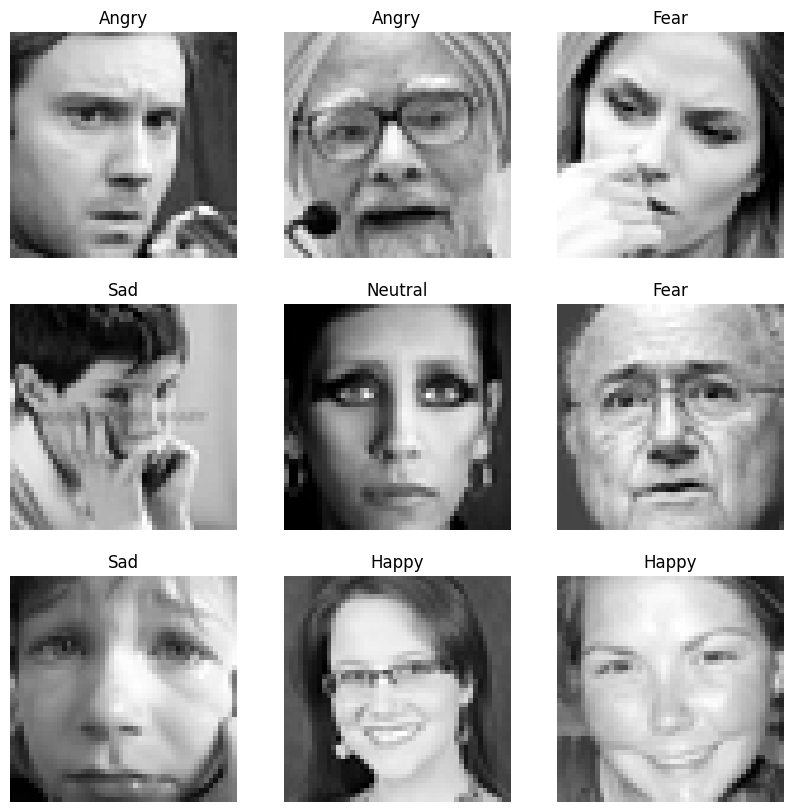

In [12]:
emotion_names = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X[i].reshape(48,48), cmap="gray")
    plt.title(emotion_names[np.argmax(y[i])])
    plt.axis("off")

plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

Training Images: (28709, 48, 48, 1)
Testing Images: (7178, 48, 48, 1)


In [1]:
import tensorflow as tf
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# 1. Download/Locate Dataset
path = kagglehub.dataset_download("nicolejyt/facialexpressionrecognition")
csv_path = os.path.join(path, "fer2013.csv")
df = pd.read_csv(csv_path)

# 2. Basic Preprocessing (keep at 48x48)
print("Converting pixels to 48x48 arrays...")
X = np.stack(df["pixels"].apply(lambda x: np.fromstring(x, sep=' ')).values)
X = X.reshape(-1, 48, 48, 1).astype("float32") / 255.0
y = to_categorical(df["emotion"], 7)

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=np.argmax(y, axis=1)
)

# 4. Create a tf.data Pipeline for efficient resizing during training
def load_and_preprocess(image, label):
    # Resize and convert to RGB on-the-fly
    image = tf.image.resize(image, (224, 224))
    image = tf.image.grayscale_to_rgb(image)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
batch_size = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1000).map(load_and_preprocess, num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE)

print("Data pipeline ready. X_train and X_test are stored at original 48x48 to save RAM.")

Using Colab cache for faster access to the 'facialexpressionrecognition' dataset.
Converting pixels to 48x48 arrays...
Data pipeline ready. X_train and X_test are stored at original 48x48 to save RAM.


In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# 1. Load MobileNetV2 with ImageNet weights, excluding the top layer
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# 2. Freeze the base model
base_model.trainable = False

# 3. Add custom layers for FER2013
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
predictions = Dense(7, activation="softmax")(x)

# 4. Compile
model = Model(inputs=base_model.input, outputs=predictions)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model compiled successfully.


In [9]:
# Evaluate the model using the test dataset pipeline
loss, accuracy = model.evaluate(test_ds)

print("Test Accuracy:", accuracy)

225/225 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.4296 - loss: 1.5053
Test Accuracy: 0.4296461343765259


In [15]:
# 1. First, you must SAVE the model you just compiled/trained
model.save("my_model.keras")
print("Model saved successfully!")

# 2. Then you can LOAD it
from tensorflow.keras.models import load_model
loaded_model = load_model("my_model.keras")
print("Model loaded successfully!")

Model saved successfully!
Model loaded successfully!


In [16]:
loss, accuracy = model.evaluate(test_ds)
print("Accuracy:", accuracy)

225/225 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.4359 - loss: 1.5206
Accuracy: 0.4359152913093567


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


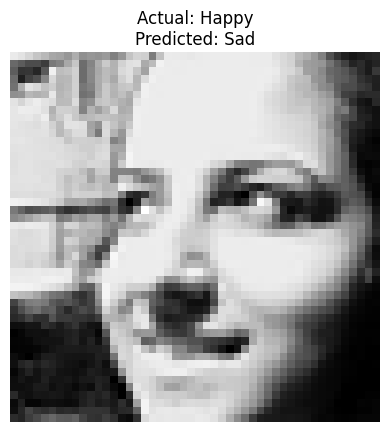

In [19]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

emotion_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

# Get a sample image from X_test (48, 48, 1)
sample_img = X_test[0:1]

# Preprocess to match model input (224, 224, 3)
input_img = tf.image.resize(sample_img, (224, 224))
input_img = tf.image.grayscale_to_rgb(input_img)

# Predict
prediction = model.predict(input_img)
predicted_class = np.argmax(prediction)
actual_class = np.argmax(y_test[0])

# Display
plt.imshow(X_test[0].reshape(48, 48), cmap='gray')
plt.axis("off")
plt.title(f"Actual: {emotion_names[actual_class]}\nPredicted: {emotion_names[predicted_class]}")
plt.show()